<a href="https://colab.research.google.com/github/y7chinmay/Data-Cleaning-and-Analysis/blob/main/Data_Cleaning_And_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Professional Data Cleaning Workflow
A real data analyst typically follows this order

1. Load data

2. Understand dataset

3. Remove duplicates

4. Handle missing values

5. Detect outliers

6. Remove outliers

7. Feature engineering

8. Analysis



1. IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. LOAD THE DATASET

In [2]:
df = pd.read_csv('employee_proper_dataset.csv')
df.head()

,Employee_ID,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
0,1229,Neha,Finance,28.0,Female,6,8,8,12,111300.0,Pune
1,1073,Karan,IT,24.0,Male,2,9,5,12,96700.0,Bangalore
2,1491,Arjun,HR,41.0,Male,19,2,11,10,950000.0,Pune
3,1086,Neha,Finance,42.0,Male,18,1,11,12,141600.0,Chennai
4,1469,Rohit,IT,32.0,Female,5,8,7,11,106600.0,Delhi


3. UNDERSTAND THE DATASET

In [3]:
df.shape

(540, 11)

MEANING:
540 ROWS
11 COLUMNS


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        540 non-null    int64  
 1   Name               540 non-null    object 
 2   Department         540 non-null    object 
 3   Age                489 non-null    float64
 4   Gender             540 non-null    object 
 5   Experience         540 non-null    int64  
 6   Performance_Score  540 non-null    int64  
 7   Projects_Handled   540 non-null    int64  
 8   Working_Hours      540 non-null    int64  
 9   Salary             483 non-null    float64
 10  City               483 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 46.5+ KB


SHOWS:

COLUMN NAMES

DATATYPE

NON-NULL COUNT

In [5]:
df.describe()

,Employee_ID,Age,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary
count,540.000000,489.000000,540.000000,540.000000,540.000000,540.000000,4.830000e+02
mean,1493.720370,37.376278,11.961111,5.268519,9.300000,8.887037,1.326219e+05
std,1446.109126,13.058723,7.447800,2.981721,4.782738,2.452559,1.226573e+05
min,1000.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+02
25%,1126.750000,30.000000,5.000000,3.000000,6.000000,7.000000,9.670000e+04
50%,1259.500000,37.000000,12.000000,5.000000,9.000000,9.000000,1.197000e+05
75%,1387.250000,43.000000,19.000000,8.000000,13.000000,11.000000,1.493500e+05
max,9999.000000,150.000000,24.000000,10.000000,19.000000,12.000000,1.500000e+06


SHOW STATISTICS VALUES:

MEAN

MEDIAN 50%

MINIMUM

MAXIMUM

STANDARD DEVIATION

COUNT

1ST QUARTILE 25%

3RD QUARTILE 75%

4.CHECK MISSING VALUES

In [6]:
df.isnull().sum()

,0
Employee_ID,0
Name,0
Department,0
Age,51
Gender,0
Experience,0
Performance_Score,0
Projects_Handled,0
Working_Hours,0
Salary,57


THIS COUNTS HOW MANY MISSING VALUES EXSIST IN EACH COLUMN

### 5. REMOVE COMPLETELY BLANK ROWS

SOMETIMES DATASETS CONTAIN ROWS WHERE EVERY COLUMN IS EMPTY

| NAME | AGE | SALARY | CITY |
| ---- | --- | ------ | ---- |
| NaN  | NaN | NaN    | NaN  |

WHERE NaN - NOT A NUMBER

In [7]:
df = df.dropna(how="all")

In [9]:
df.shape

(540, 11)

6. REMOVE DUPLICATE ROWS

EXAMPLE-

| Name  | Age | Salary |
| ----- | --- | ------ |
| RAM | 35  | 70000  |
| RAM | 35  | 70000  |

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(512, 11)

7.DROP UNNECESSARY COLUMNS

In [12]:
df = df.drop("Employee_ID", axis=1)



In [13]:
df.head()

,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
0,Neha,Finance,28.0,Female,6,8,8,12,111300.0,Pune
1,Karan,IT,24.0,Male,2,9,5,12,96700.0,Bangalore
2,Arjun,HR,41.0,Male,19,2,11,10,950000.0,Pune
3,Neha,Finance,42.0,Male,18,1,11,12,141600.0,Chennai
4,Rohit,IT,32.0,Female,5,8,7,11,106600.0,Delhi


In [15]:
df.shape

(512, 10)

8. HANDLING MISSING AGE VALUES

In [16]:
df["Age"].isnull().sum()

np.int64(38)

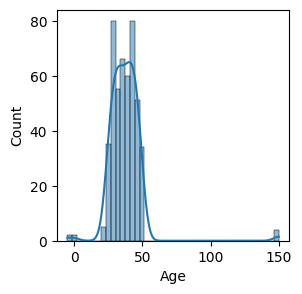

In [17]:

plt.figure(figsize=(3,3))
sns.histplot(df["Age"],kde=True)
plt.show()



WE HAVE WRONG VALUES IN AGE COLUMN. SO WE WILL REMOVE OUTLIERS FROM AGE AND THEN WILL REPLACE NULL VALUES.

 MEAN REPRESENTS THE AVERAGE AGE OF EMPLOYEES.

 THEREFORE MISSING AGES ARE REPLACED WITH THE MEAN AGE.

DETECT OUTLIERS

BEFORE DECIDING MEAN OR MEDIAN WE CHECK FOR OUTLIERS.

AN OUTLIER IS A VALUE THAT IS EXTREMELY HIGHER OR LOWER THAN OTHER VALUES.

EXAMPLE-

31000

32000

35000

37000

100000 <- OUTLIER

METHOD 1: BOXPLOT (VISUAL METHOD)

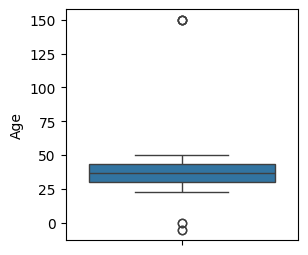

In [18]:
plt.figure(figsize=(3,3))
sns.boxplot(df["Age"])
plt.show()

METHOD 2: IQR METHOD (MATHEMATICAL METHOD)

IQR = INTER QUARTIL RANGE IQR = Q3-Q1 WHERE

Q1 = 25TH PERCENTILE

Q3 = 75TH PERCENTILE

OUTLIER RANGE:

LOWER LIMIT = Q1-1.5*IQR

UPPER LIMIT = Q3+1.5*IQR

In [19]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Age"] < lower_limit) | (df["Age"] > upper_limit)]
outliers

,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
144,Vikram,Finance,-5.0,Female,23,9,19,12,172600.0,Pune
223,John,Operations,0.0,Female,22,5,14,6,149300.0,Mumbai
315,Simran,Marketing,150.0,Male,16,9,13,7,142100.0,Hyderabad
365,Amit,Operations,150.0,Female,19,9,14,8,154200.0,Delhi
409,Manish,Finance,150.0,Female,22,3,14,8,153600.0,Pune
442,Anjali,HR,0.0,Male,1,2,2,6,59500.0,Chennai
482,Anita,IT,150.0,Male,2,8,5,12,99400.0,Mumbai
521,Neha,Finance,-5.0,Female,22,7,14,10,163500.0,Hyderabad


In [20]:
# if you use below method it will remove outliers along with null values, and we will loose our data
#df = df[(df["Age"] >= lower_limit) & (df["Age"] <= upper_limit)]

# To avoid this we will use clip() method. which will remove outliers except null
df['Age']=df['Age'].clip(lower_limit,upper_limit)

In [21]:
df.shape

(512, 10)

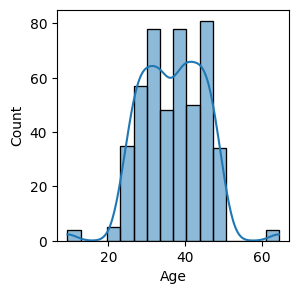

In [22]:
plt.figure(figsize=(3,3))
sns.histplot(df["Age"],kde=True)
plt.show()

In [23]:
df["Age"].isnull().sum()

np.int64(38)

In [24]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [25]:
df["Age"].isnull().sum()

np.int64(0)

9.HANDLING MISSING SALARY VALUES

In [26]:
df["Salary"].isnull().sum()

np.int64(44)

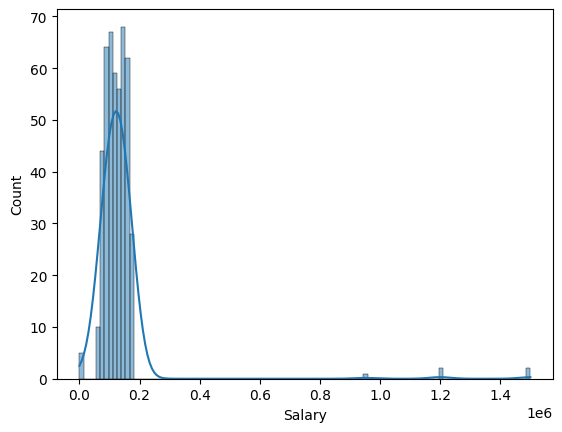

In [27]:
sns.histplot(df["Salary"],kde=True)
plt.show()


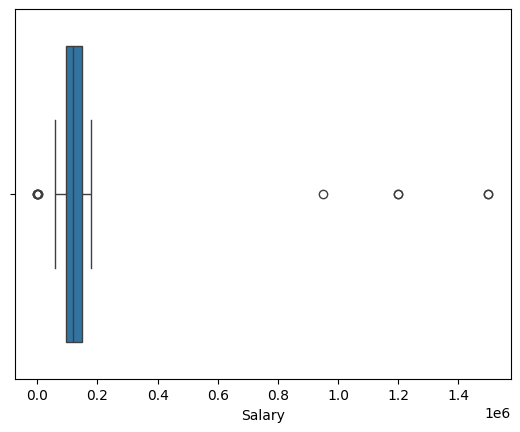

In [28]:
sns.boxplot(x=df["Salary"])
plt.show()

In [29]:
df['Salary'].describe()

,Salary
count,4.680000e+02
mean,1.329558e+05
std,1.245291e+05
min,2.000000e+02
25%,9.547500e+04
50%,1.201500e+05
75%,1.495250e+05
max,1.500000e+06


In [30]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Salary"] < lower_limit) | (df["Salary"] > upper_limit)]
outliers

,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
2,Arjun,HR,41.0,Male,19,2,11,10,950000.0,Pune
22,Priya,IT,24.0,female,2,4,2,10,500.0,Mumbai
35,Arjun,Operations,36.0,Female,14,8,11,11,1000.0,Chennai
160,Manish,Operations,38.0,Female,16,8,11,12,1500000.0,Delhi
196,Manish,Operations,28.0,Male,3,10,6,10,1500000.0,Hyderabad
255,Rohit,Operations,39.0,Male,16,1,9,9,200.0,Mumbai
287,Kavya,Operations,31.0,Male,5,8,7,6,1000.0,Chennai
331,Suresh,IT,46.0,Female,19,1,14,9,500.0,Mumbai
337,Priya,IT,32.0,Female,5,4,3,6,1200000.0,NaN
537,Vikram,HR,47.0,Male,23,3,15,11,1200000.0,Pune


In [31]:
outliers.shape

(10, 10)

In [32]:
df['Salary']=df['Salary'].clip(lower_limit,upper_limit)

In [33]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

SALARY USUALLY HAS OUTLIERS (VERY HIGH SALARIES)

MEAN WOULD BECOME EXTREMELY HIGH

MEDIAN GIVES THE MIDDILE VALUE WHICH IS MORE RELIABLE

THUS MEDIAN IS PREFERRED WHEN OUTLIERS EXIST.

In [34]:
df["Salary"].isnull().sum()

np.int64(0)

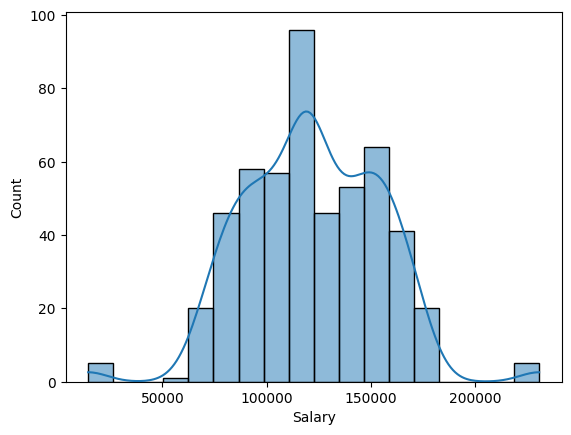

In [35]:
sns.histplot(df["Salary"],kde=True)
plt.show()

10. HANDLING MISSING CITY VALUES

WHY MODE?

CITY IS CATEGORICAL DATA.

MEAN OR MEDIAN CANNOT BE APPLIED.

MODE RETURNS THE MOST FRQUENT CITY

In [36]:
df["City"].isnull().sum()

np.int64(43)

In [37]:
df["City"].mode()[0]

'Chennai'

In [38]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

In [39]:
df.isnull().sum()

,0
Name,0
Department,0
Age,0
Gender,0
Experience,0
Performance_Score,0
Projects_Handled,0
Working_Hours,0
Salary,0
City,0


11. DATA ANALYSIS

SORTING


In [40]:
## TOP 10 HIGHEST SALARY EMPLOYEES
df.sort_values(by="Salary", ascending=False).head(10)

,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
2,Arjun,HR,41.0,Male,19,2,11,10,230600.0,Pune
537,Vikram,HR,47.0,Male,23,3,15,11,230600.0,Pune
160,Manish,Operations,38.0,Female,16,8,11,12,230600.0,Delhi
196,Manish,Operations,28.0,Male,3,10,6,10,230600.0,Hyderabad
337,Priya,IT,32.0,Female,5,4,3,6,230600.0,Chennai
146,Suresh,IT,48.0,Male,24,8,17,6,179700.0,Chennai
475,Manish,Finance,45.0,Male,23,9,18,6,178800.0,Chennai
27,Aarav,IT,50.0,Female,23,6,16,8,177300.0,Bangalore
139,Ajay,IT,44.0,Male,22,10,17,11,175200.0,Mumbai
293,Ajay,HR,49.0,Female,24,3,17,7,174500.0,Hyderabad


In [41]:
# sort by experience
df.sort_values(by="Experience", ascending=False).head(10)

,Name,Department,Age,Gender,Experience,Performance_Score,Projects_Handled,Working_Hours,Salary,City
507,Meena,Operations,50.0,Female,24,10,19,9,171300.0,Mumbai
29,Ajay,Finance,46.0,Male,24,3,15,12,169500.0,Chennai
17,Neha,Finance,50.0,Male,24,10,18,7,171300.0,Bangalore
34,Meena,Sales,47.0,Female,24,6,17,11,171300.0,Delhi
476,Manish,Sales,46.0,Male,24,5,17,10,167300.0,Bangalore
457,Anita,Sales,48.0,Male,24,4,16,7,161000.0,Chennai
90,John,Sales,49.0,Female,24,5,16,12,167600.0,Delhi
85,Simran,IT,50.0,Male,24,3,16,10,165800.0,Mumbai
100,Kavya,Marketing,49.0,Male,24,6,18,9,161800.0,Delhi
103,John,HR,49.0,Male,24,5,16,12,160600.0,Chennai


GROUP BY ANALYSIS

AVERAGE SALARY BY DEPARTMENT


In [42]:
df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

,Salary
Department,
HR,133466.666667
IT,131887.912088
Finance,125940.769231
Operations,123499.473684
Finance,121116.666667
IT,120725.000000
Sales,117924.404762
HR,117507.558140
Marketing,114693.421053


THIS SHOWS WHICH DEPARTMENT PAYS THE HIGHEST SALARY

EMPLOYEE COUNT PER CITY

In [43]:
df.groupby("City")["Name"].count().sort_values()

,Name
City,
Hyderabad,69
Delhi,74
Pune,76
Mumbai,80
Bangalore,82
Chennai,131


In [44]:
df["Gender"].unique() #need to clean

array(['Female', 'Male', 'male', 'female', 'F', 'FEMALE', 'MALE', 'M'],
      dtype=object)

In [45]:
df["Gender"]=df["Gender"].str.lower()

In [46]:
df["Gender"] = df["Gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female",
    "fem": "Female"
})

In [47]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [48]:
df["Department"].unique()

array(['Finance', 'IT', 'HR', 'Operations', 'Sales', 'Marketing', 'HR ',
       'IT ', ' Finance', 'it', 'operations'], dtype=object)

In [49]:
df["Department"]=df["Department"].str.strip()

In [50]:
df["Department"]=df["Department"].replace({"it":"IT"})

In [51]:
df["Department"].unique()

array(['Finance', 'IT', 'HR', 'Operations', 'Sales', 'Marketing',
       'operations'], dtype=object)

In [52]:
df.groupby(["Department","Gender"])["Salary"].mean() #average salary of each department for each gender

Department  Gender
Finance     Female    123450.000000
            Male      128791.379310
HR          Female    108915.384615
            Male      125167.000000
IT          Female    131656.666667
            Male      129053.773585
Marketing   Female    111745.348837
            Male      118534.848485
Operations  Female    127240.909091
            Male      118355.000000
Sales       Female    116747.500000
            Male      118994.318182
operations  Female    103475.000000
Name: Salary, dtype: float64

In [53]:
df1=df.groupby(["Department","Gender"])["Salary"].mean()
df2=df1.unstack()
df2.head()

Gender,Female,Male
Department,,
Finance,123450.000000,128791.379310
HR,108915.384615,125167.000000
IT,131656.666667,129053.773585
Marketing,111745.348837,118534.848485
Operations,127240.909091,118355.000000


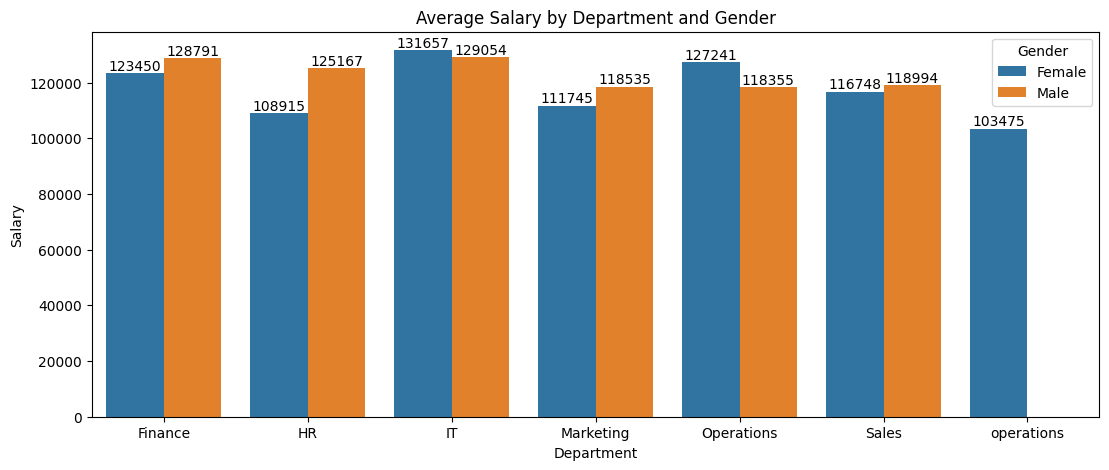

In [54]:

df1=df.groupby(["Department","Gender"])["Salary"].mean().reset_index()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13,5))
ax=sns.barplot(x="Department", y="Salary", hue="Gender", data=df1)
for i in ax.containers:
    ax.bar_label(i)

plt.title("Average Salary by Department and Gender")

plt.show()

In [55]:
df["City"].unique()

array(['Pune', 'Bangalore', 'Chennai', 'Delhi', 'Mumbai', 'Hyderabad'],
      dtype=object)

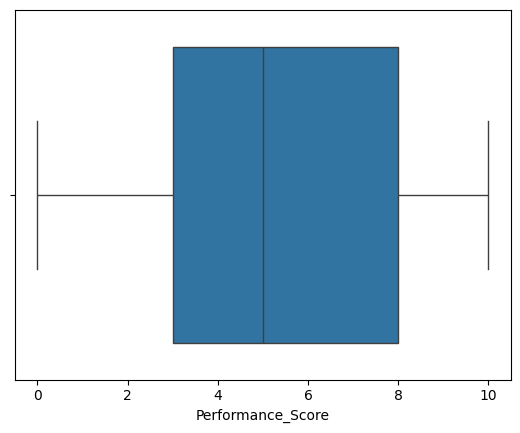

In [56]:
sns.boxplot(x=df["Performance_Score"])
plt.show()

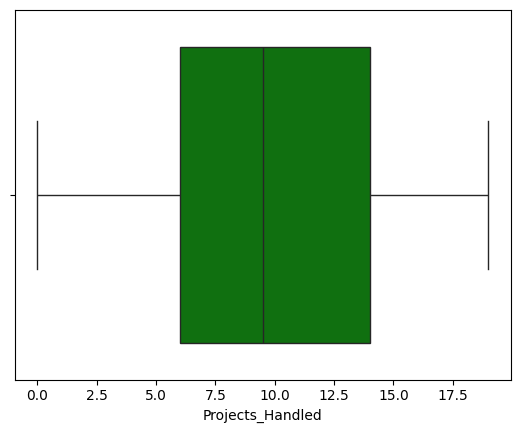

In [57]:
sns.boxplot(x=df["Projects_Handled"],color="green")
plt.show()

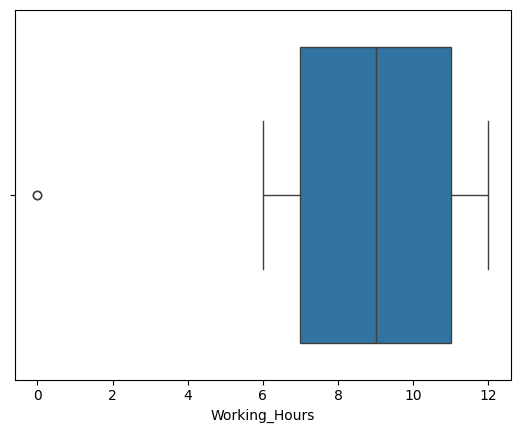

In [58]:
sns.boxplot(x=df["Working_Hours"])
plt.show()

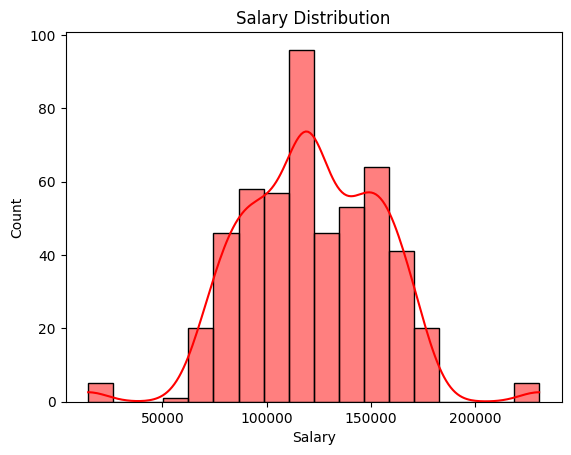

In [59]:
sns.histplot(df["Salary"], kde=True,color="red")
plt.title("Salary Distribution")
plt.show()

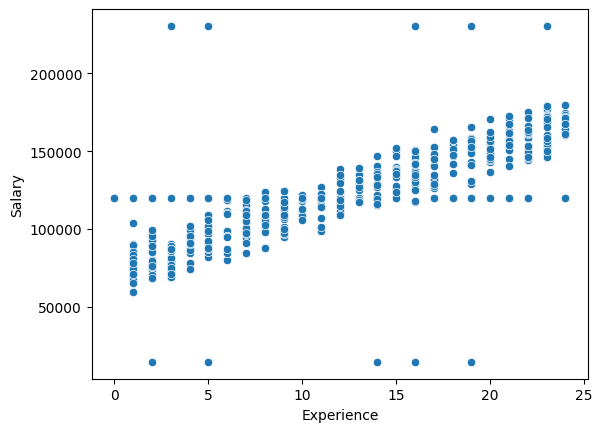

In [60]:
sns.scatterplot(x="Experience",y="Salary",data=df)
plt.show()

In [61]:
df["Experience"].corr(df["Salary"])

np.float64(0.8134636242971691)

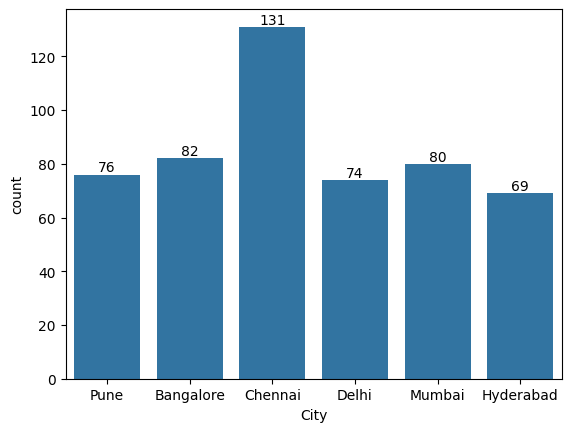

In [62]:
#sns.countplot(x="City",data=df)
ax = sns.countplot(x="City", data=df)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

In [63]:
ax.containers

[<BarContainer object of 6 artists>]

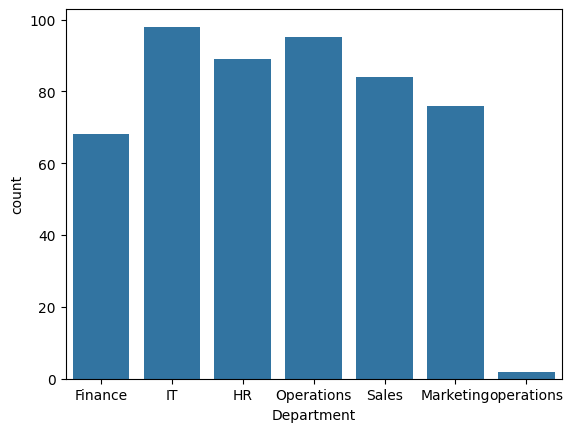

In [64]:
# Employee per department
sns.countplot(x="Department", data=df)
plt.show()

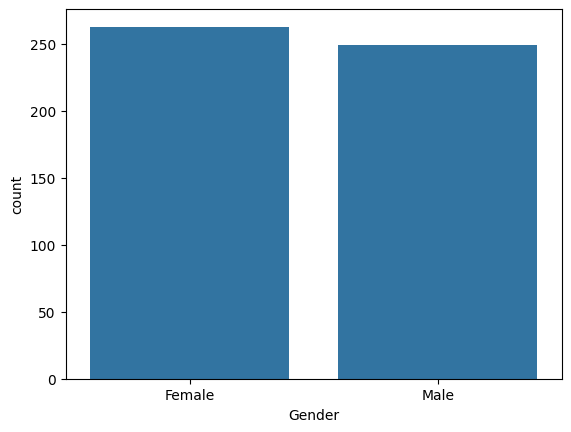

In [65]:
# gender distribution
sns.countplot(x="Gender", data=df)
plt.show()

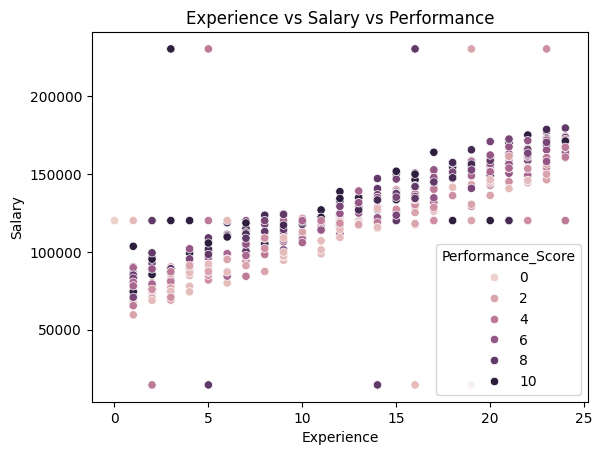

In [66]:
# Experience vs Performance vs Salary

sns.scatterplot(x="Experience", y="Salary", hue="Performance_Score", data=df)

plt.title("Experience vs Salary vs Performance")

plt.show()

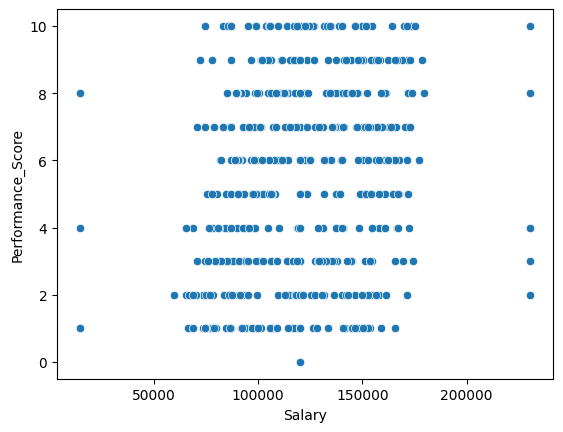

In [67]:
# performance vs Salary
sns.scatterplot(x="Salary", y="Performance_Score", data=df)
plt.show()

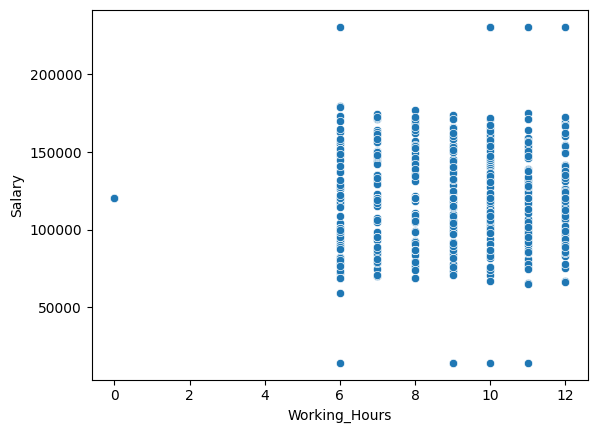

In [68]:
# working hours vs performance
sns.scatterplot(x="Working_Hours", y="Salary", data=df)
plt.show()